In [12]:
import torch
from transformers import AutoTokenizer, EsmModel
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# load model tokenizer
model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name)
model.eval()

# Define the p53 Wild-Type (WT) sequence
p53_wt = "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPGGSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD"

# Generate embedding
inputs = tokenizer(p53_wt, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

# This is the 'Representation' of the whole protein
# Take the mean of all amino acid vectors to get a single 'fingerprint'
p53_representation = outputs.last_hidden_state.mean(dim=1)

print(f"p53 Representation Shape: {p53_representation.shape}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


p53 Representation Shape: torch.Size([1, 1280])


tensor([[ 0.0190, -0.0501, -0.0012,  ..., -0.1001,  0.0122,  0.0131]])


In [11]:
p53_mutant = p53_wt[:247] + 'Q' + p53_wt[248:]
p53_mutant
p53_mutant[245:250]

'MNQRP'

In [13]:
inputs2 = tokenizer(p53_mutant, return_tensors="pt")
with torch.no_grad():
    outputs2 = model(**inputs2)

p53_mut_repr = outputs2.last_hidden_state.mean(dim=1)

print(f"p53 mut Representation Shape: {p53_mut_repr.shape}")

p53 mut Representation Shape: torch.Size([1, 1280])


In [14]:
similarity = cosine_similarity(p53_representation, p53_mut_repr)
print(f"Similarity between WT and Mutant: {similarity[0][0]:.6f}")

Similarity between WT and Mutant: 0.999951


In [37]:
import matplotlib.pyplot as plt

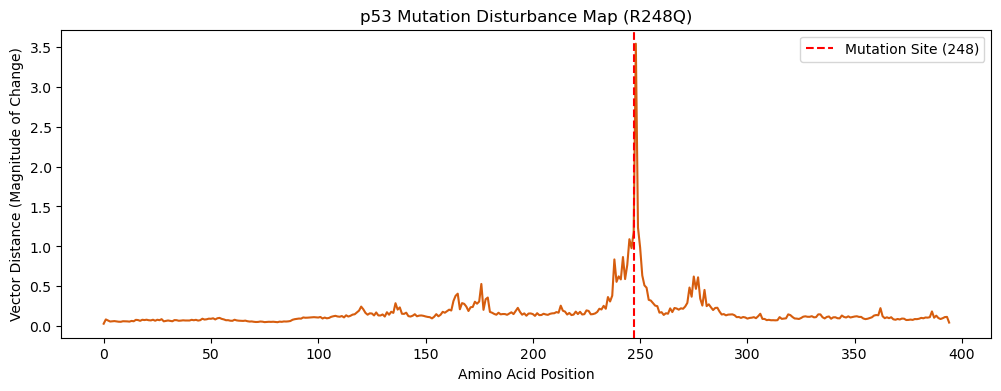

In [38]:
# 1. Calculate the Euclidean distance between WT and Mutant at every position
# shape: (393, 1280)
diffs = torch.norm(outputs.last_hidden_state[0] - outputs2.last_hidden_state[0], dim=1).numpy()

# 2. Plot the 'Disturbance Map'
plt.figure(figsize=(12, 4))
plt.plot(diffs, color='#d65d0e') # Using a warm Gruvbox-style orange
plt.title("p53 Mutation Disturbance Map (R248Q)")
plt.xlabel("Amino Acid Position")
plt.ylabel("Vector Distance (Magnitude of Change)")
plt.axvline(x=247, color='red', linestyle='--', label='Mutation Site (248)')
plt.legend()
plt.show()

In [39]:
# Slicing the hidden states: [batch, sequence_length, embedding_dim]
wt_dbd = outputs.last_hidden_state[:, 102:292, :]
mut_dbd = outputs2.last_hidden_state[:, 102:292, :]

# Calculate the mean of just the DBD
wt_dbd_mean = wt_dbd.mean(dim=1)
mut_dbd_mean = mut_dbd.mean(dim=1)

dbd_similarity = cosine_similarity(wt_dbd_mean, mut_dbd_mean)
print(f"DBD-only Similarity: {dbd_similarity[0][0]:.6f}")

DBD-only Similarity: 0.999841
